In [ ]:
import random
import pandas as pd

In [ ]:

# Define items with (weight, value) pairs
items = [(50, 5), (94, 76), (31, 88), (71, 84), (91, 15), (19, 47), (12, 44), (1, 49),
         (10, 7), (16, 19), (3, 78), (57, 69), (27, 14), (99, 40), (52, 58),
         (93, 79), (50, 48), (39, 20), (26, 39), (40, 14)]
items = pd.DataFrame(items, columns=['weight', 'value'])
items.index.name = "items"

In [ ]:
items.T # transpose for better view

items,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
weight,50,94,31,71,91,19,12,1,10,16,3,57,27,99,52,93,50,39,26,40
value,5,76,88,84,15,47,44,49,7,19,78,69,14,40,58,79,48,20,39,14


In [ ]:
totalWeightLimit = 200

In [ ]:
genome = [random.randint(0,5) == 0 for _ in range(len(items))]
print(len(genome), len(items))
print(genome)


20 20
[False, False, False, False, False, True, False, False, False, True, False, True, False, False, False, False, False, False, False, False]


In [ ]:
def createPopulation(size: int): # we must make a population of genomes as a initiator
  return [[random.randint(0,5) == 0 for _ in range(len(items))] for _ in range(size)]

In [ ]:
def fitness(genes: list):
  totalWeight = 0
  totalValue = 0

  idx = 0
  for gene in genes:
    if gene:
      totalWeight += items['weight'][idx]
      totalValue += items['value'][idx]
    idx+=1

  if totalWeight > totalWeightLimit :
    return 0
  else :
    return totalValue

In [ ]:
def SelectWinners(population: list):
  populationValues = []
  for genes in population:
    value = fitness(genes=genes)
    if value>0 :
      populationValues.append((value,genes))
  # We have value, and base upon them we could sort the fittest genes
  sorted_population = sorted(populationValues, key=lambda x: x[0], reverse=True)
  return [genes for value, genes in  sorted_population]

In [ ]:
# percentage defines the percent allowed to carry forward thee genes
# among winners perfects are tarfeted, whose fitness is highest
# here we allow only 2% of population to reproduce
def SelectBest(winners: list, population: list, percentage=0.2):
  limit = int(percentage*len(population))
  if len(winners) > limit:
    best = winners[:limit]
  else:
    best = winners
  return best


## Before passing genes to nest generation we must perform cross over

In [ ]:
def CrossOver(genes1: list, genes2: list):
  crossoverpoint = random.randint(1,len(genes1)-1)
  newGenes = genes1[:crossoverpoint] + genes2[crossoverpoint:]
  return newGenes

## The newly reproduced gene has a chance of mutation, in order to simulate mutation we will create another function

In [ ]:
def mutate(genes:list):
  newGenes = list(genes) # copy of gene
  idx = random.randint(0, len(genes)-1) # selecting randome point of mutation
  newGenes[idx] = not bool(genes[idx])
  return newGenes

## We know only a small population can go mutations since it has low probability, we create a function which allow mutation to be performed to slight portion of population

## Now we start to implement our algorithm to capture reproduction and formation of next generation

In [ ]:
def nextGeneration(population: list):
  newPopulation = []

  winners = SelectWinners(population)

  if len(winners)>0:
    winners = SelectBest(winners, population, 0.2)
    for _ in range(len(population)):
      parent1, parent2 = random.sample(winners, k=2)
      newGenes = CrossOver(parent1,parent2)
      if random.random() < 0.05:
        newGenes = mutate(newGenes)
      newPopulation.append(newGenes)
  else:
    newPopulation = createPopulation(len(population))

  return newPopulation

In [ ]:
population = createPopulation(1000)
for i in range(20):
  newPopulation = nextGeneration(population)
  population = newPopulation

In [ ]:
print(len(population))

1000


In [ ]:
results = pd.concat([pd.DataFrame(population).mean()*100, items], axis=1)
results.columns = ["selection_rate"] + list(items.columns)
results.index.name = items.index.name
results.T

items,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
selection_rate,0.3,0.3,100.0,0.0,0.1,99.9,99.8,99.9,0.2,0.3,99.9,100.0,0.0,0.4,0.1,0.2,99.7,0.1,99.7,0.2
weight,50.0,94.0,31.0,71.0,91.0,19.0,12.0,1.0,10.0,16.0,3.0,57.0,27.0,99.0,52.0,93.0,50.0,39.0,26.0,40.0
value,5.0,76.0,88.0,84.0,15.0,47.0,44.0,49.0,7.0,19.0,78.0,69.0,14.0,40.0,58.0,79.0,48.0,20.0,39.0,14.0


<Axes: xlabel='items'>

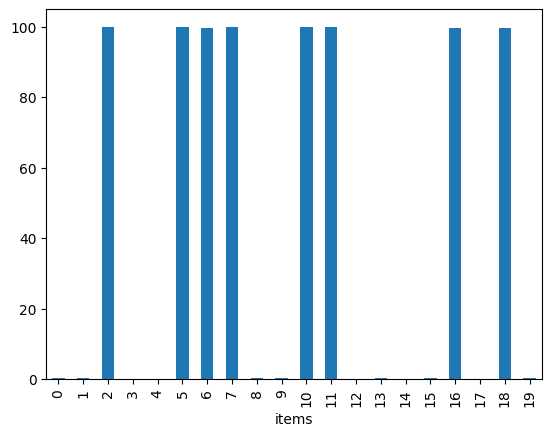

In [ ]:
results["selection_rate"].plot.bar()